# 2D Bayesian Inference for the IBM Quantum Dataset

**Tzak Lau**  


---

## 1. Introduction

Parameter estimation is widely prevalent in both physics and statistics. When measuring oscillatory signals in quantum experiments, the frequency reveals information about the behavior of systems. However, real experimental data is often affected by systematic offsets, making reliable estimation much more difficult than in idealized textbook settings.



This report studies frequency estimation using collected data from Quantum instruments. The measured outcomes display oscillatory behavior consistent with a Ramsey-type precession experiment. The goal of this report is to estimate the unknown parameters of this signal directly from this data.


There are two approaches to be considered when doing this. The first method, standard nonlinear curve fitting can be used as a baseline deterministic method. Then, Bayesian inference is applied to produce a full posterior distribution over model parameters. Bayesian methods are especially useful because they quantify uncertainty rather than just returning only a single best-fit value.



The main goal of this is a two-dimensional Bayesian model that estimates both the oscillation frequency and a phase offset.

---

## 2. Experimental Dataset

Two datasets are used:

1. **Averaged measurement data**: the fraction of positive outcomes measured at each evolution time.
2. **Raw single-shot data**: binary outcomes used directly for Bayesian likelihood calculations.

The averaged data is useful for visualization, while the raw data preserves the full statistical structure required for inference.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit
from scipy.special import logsumexp

These lines of codes imports the numerical, plotting, optimization, and probability tools used in the solution. NumPy handles arrays, Matplotlib creates the plots, pickle loads the IBM data files, curve_fit performs nonlinear least-squares fitting, and logsumexp keeps the Bayesian likelihood calculation numerically stable.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving IBM_dirp.data to IBM_dirp.data
Saving IBM_dirp_raw.data to IBM_dirp_raw.data


The upload cell loads allows files to be uplaoded (in this case the two IBM datasets). The averaged dataset is used for plotting the fraction of + outcomes at each time point. The raw single-shot dataset is used for Bayesian inference because the likelihood is naturally defined on individual binary measurement outcomes.

In [3]:
with open("IBM_dirp.data", "rb") as f:
    xs, ys = pickle.load(f)

with open("IBM_dirp_raw.data", "rb") as f:
    xs_raw, ys_raw = pickle.load(f)

print("Averaged data points:", len(xs))
print("Raw single-shot samples:", len(xs_raw))

Averaged data points: 20
Raw single-shot samples: 400


The baseline model assumes the ideal probability curve P(+|t)=cos²(ωt/2). This is useful as a first check, but it forces the curve to have no phase shift, so it cannot fully match the IBM data.

## 3. Baseline Curve Fitting

A natural first model for oscillatory data is

$$
P(+|t)=\cos^2\left(\frac{\omega t}{2}\right)
$$

where $\omega$ is the unknown frequency.

This idealized form works well for simulated data, but real hardware measurements may also include phase shifts and calibration effects.

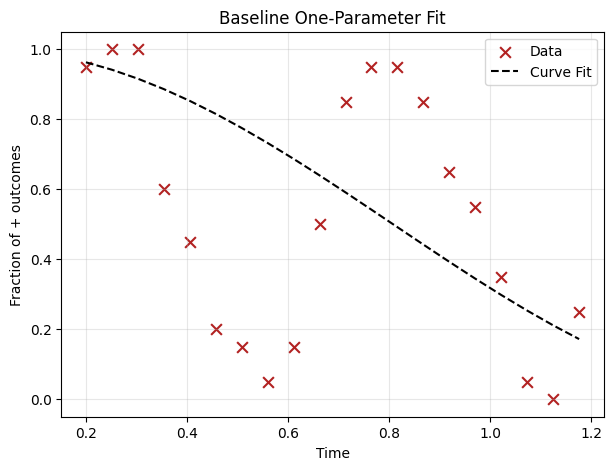

Estimated omega: 1.945026450396578


In [4]:
def simple_model(t, w):
    return np.cos(w*t/2)**2

params, _ = curve_fit(simple_model, xs, ys, p0=[0.5], maxfev=10000)
w_fit = params[0]

pred_simple = simple_model(xs, w_fit)

plt.figure(figsize=(7,5))
plt.scatter(xs, ys, color="firebrick", marker="x", s=60, label="Data")
plt.plot(xs, pred_simple, "k--", label="Curve Fit")
plt.title("Baseline One-Parameter Fit")
plt.xlabel("Time")
plt.ylabel("Fraction of + outcomes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Estimated omega:", w_fit)

The one-parameter fit captures the rough periodic structure, but mismatches remain. This calls for a more flexible model.

## 4. Two-Parameter Oscillation Model

To better represent the IBM data, the model is generalized to

$$
P(+|t)=\frac{1}{2}\left(1+\cos(\omega t+\phi)\right)
$$

where:

- $\omega$ = oscillation frequency  
- $\phi$ = phase offset  

This retains physical interpretability while allowing horizontal shifts in the signal.

In [5]:
def prob_2d(t, w, phi, eps=1e-10):
    p = 0.5*(1 + np.cos(w*t + phi))
    return np.clip(p, eps, 1-eps)

## 5. Bayesian Inference in Two Dimensions

Rather than selecting only one best-fit parameter pair, Bayesian inference computes the posterior probability over all candidate values of $(\omega,\phi)$.

Using Bayes' rule:

$$
P(\omega,\phi \mid D)\propto P(D\mid \omega,\phi)\,P(\omega,\phi)
$$

where $D$ denotes the raw IBM measurement outcomes.

Assuming a uniform prior, the posterior is proportional to the likelihood.

In [6]:
def bayesian_estimate_2d(ts, ys, w_domain, phi_domain, Nw=400, Nphi=400):
    ws = np.linspace(w_domain[0], w_domain[1], Nw)
    phis = np.linspace(phi_domain[0], phi_domain[1], Nphi)

    log_post = np.empty((Nw, Nphi))

    for i, w in enumerate(ws):
        p = prob_2d(ts[:, None], w, phis[None, :])
        logL = ys[:, None]*np.log(p) + (1-ys)[:, None]*np.log(1-p)
        log_post[i, :] = np.sum(logL, axis=0)

    logZ = logsumexp(log_post)
    post = np.exp(log_post - logZ)

    idx = np.unravel_index(np.argmax(post), post.shape)
    w_map = ws[idx[0]]
    phi_map = phis[idx[1]]

    post_w = np.sum(post, axis=1)

    return w_map, phi_map, ws, phis, post, post_w

In [7]:
w_map, phi_map, ws, phis, post, post_w = bayesian_estimate_2d(
    xs_raw, ys_raw,
    w_domain=(0, 30),
    phi_domain=(-np.pi, np.pi)
)

print("MAP omega:", w_map)
print("MAP phi:", phi_map)

MAP omega: 10.977443609022556
MAP phi: -2.842393353247908


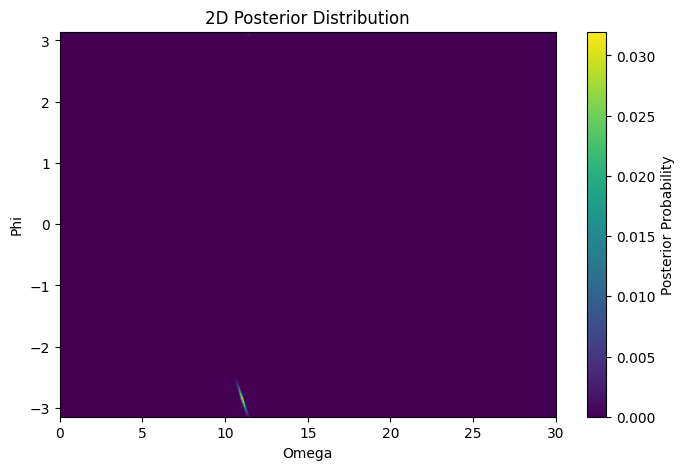

In [8]:
plt.figure(figsize=(8,5))
plt.imshow(
    post.T,
    aspect="auto",
    origin="lower",
    extent=[ws[0], ws[-1], phis[0], phis[-1]]
)
plt.colorbar(label="Posterior Probability")
plt.xlabel("Omega")
plt.ylabel("Phi")
plt.title("2D Posterior Distribution")
plt.show()

This posterior heatmap shows which combinations of frequency and phase are most consistent with the IBM data. The bright concentrated region near $ \omega \approx 11 $ identifies the most likely parameter values. Its narrow shape suggests a precise estimate of the oscillation frequency.

## 6. Results

### Marginal Posterior of Frequency



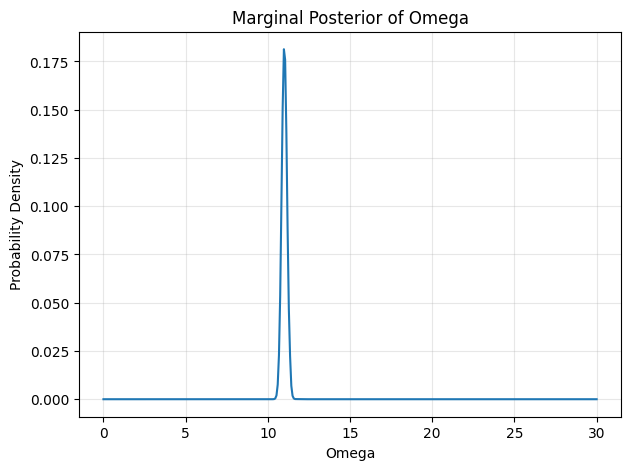

In [9]:
plt.figure(figsize=(7,5))
plt.plot(ws, post_w)
plt.title("Marginal Posterior of Omega")
plt.xlabel("Omega")
plt.ylabel("Probability Density")
plt.grid(alpha=0.3)
plt.show()

The posterior is sharply concentrated, indicating that the dataset strongly constrains the oscillation frequency.

### Final Bayesian Fit


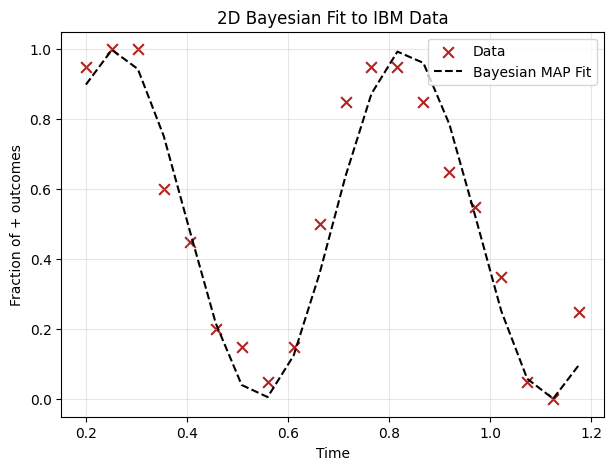

In [10]:
pred = prob_2d(xs, w_map, phi_map)

plt.figure(figsize=(7,5))
plt.scatter(xs, ys, color="firebrick", marker="x", s=60, label="Data")
plt.plot(xs, pred, "k--", label="Bayesian MAP Fit")
plt.title("2D Bayesian Fit to IBM Data")
plt.xlabel("Time")
plt.ylabel("Fraction of + outcomes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The fitted curve closely tracks the measured IBM data, showing that the two-parameter model successfully captures the dominant oscillatory behavior.

## 7. Additional Discussion: Maximum Likelihood and Optimization

Bayesian inference uses the full posterior distribution over parameters, but a related deterministic approach is maximum likelihood estimation (MLE). In MLE, one chooses the parameter values that maximize the likelihood of observing the measured data.

For the two-parameter model used here, MLE would require solving a nonlinear optimization problem over $(\omega,\phi)$. Common numerical methods include gradient-based optimization, grid search, Nelder-Mead, and Levenberg-Marquardt style least-squares methods.

Bayesian inference can be viewed as a generalization of this idea: instead of returning only the single best point estimate, it evaluates the entire parameter landscape and quantifies uncertainty.

In low-dimensional problems such as this notebook, both MLE and Bayesian grid methods are practical. In higher-dimensional settings, optimization efficiency becomes increasingly important.

In [11]:
print("Curve Fit omega:", w_fit)
print("Bayesian MAP omega:", w_map)
print("Posterior mean omega:", np.sum(ws*post_w))

Curve Fit omega: 1.945026450396578
Bayesian MAP omega: 10.977443609022556
Posterior mean omega: 11.008782571958879


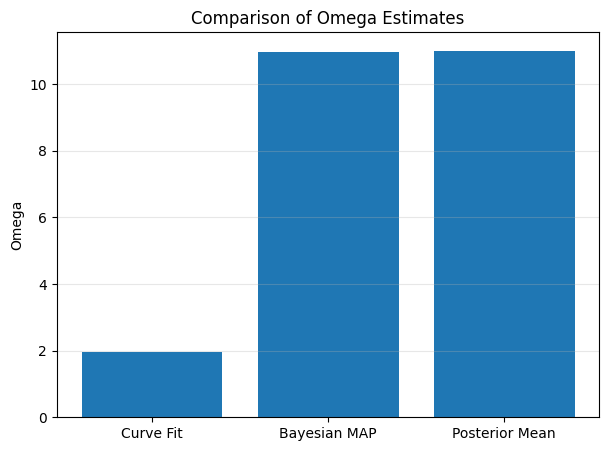

In [12]:
labels = ["Curve Fit", "Bayesian MAP", "Posterior Mean"]
omegas = [w_fit, w_map, np.sum(ws * post_w)]

plt.figure(figsize=(7,5))
plt.bar(labels, omegas)
plt.title("Comparison of Omega Estimates")
plt.ylabel("Omega")
plt.grid(axis="y", alpha=0.3)
plt.show()

This plot compares the frequency estimate from the baseline curve fit with the Bayesian MAP estimate and posterior mean. The Bayesian MAP and posterior mean are very close, which shows that the posterior is sharply centered around one frequency value. The baseline curve fit gives a different value because the simpler model is less flexible.

## 8. Conclusion

This notebook investigated parameter estimation for IBM quantum measurement data using both deterministic and probabilistic methods.

A simple one-parameter fit provided an initial approximation, but a two-parameter Bayesian model produced a more principled and flexible solution. By estimating both frequency and phase simultaneously, the method accurately reproduced the observed oscillatory signal while quantifying parameter confidence.

The same framework can be extended to richer physical models, decoherence effects, or larger quantum datasets in future work.